This notebook compares data from test runs to the trajectories that the vehicle follows. This script currently compares:
- Stopping positions
- Distance to last traj point
- Average distance to the path
- Time duration of test runs

In [2]:
import os
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import re

In [3]:
def log_to_df(file_path) -> pd.DataFrame:
  columns = [
    "timestamp", "client_id", "client_ip", "x", "y", "z", 
    "yaw", "speed_lon", "speed_lat", "acc_lon", "acc_lat", 
    "driving_dir", "ready", "error_status"
	]
 
  pattern = re.compile(
    r"^\d+\.\d+: \d+\.\d+;\d+;(?:\d{1,3}\.){3}\d{1,3};"
    r"[+-]?\d+\.\d+;[+-]?\d+\.\d+;[+-]?\d+\.\d+;"  # Coordinates and numeric fields
    r"[+-]?\d+\.\d+;[+-]?\d+\.\d+;[+-]?\d+\.\d+;"  # Speeds and accelerations
    r"(?:[+-]?\d+\.\d+|[a-zA-Z_]+);"              # Acceleration 1: number or string
    r"(?:[+-]?\d+\.\d+|[a-zA-Z_]+);"              # Acceleration 2: number or string
    r"[a-zA-Z_]+;"                                # Driving direction (e.g., NaN)
    r"[a-zA-Z_]+;"                                # Ready status (e.g., ARMED)
    r"[a-zA-Z_]+;"                                # Error status (e.g., NOT_READY_TO_ARM)
    r"[a-zA-Z_]+;$"                               # Final status (e.g., OK)
  )
  
  data = []
  with open(file_path, "r") as file:
    for line in file:
      if pattern.match(line.strip()):
        relevant_part = line.split(":", 1)[1].strip()
        values = relevant_part.split(";")
        values = values[:14]
        data.append(values)
    
  df = pd.DataFrame(data, columns=columns)
  df['timestamp'] = df['timestamp'].apply(pd.to_numeric, errors="coerce")
  df['client_id'] = df['client_id'].apply(pd.to_numeric, errors="coerce")
  df['x'] = df['x'].apply(pd.to_numeric, errors="coerce")
  df['y'] = df['y'].apply(pd.to_numeric, errors="coerce")
  df['z'] = df['z'].apply(pd.to_numeric, errors="coerce")
  df['yaw'] = df['yaw'].apply(pd.to_numeric, errors="coerce")
  df['speed_lon'] = df['speed_lon'].apply(pd.to_numeric, errors="coerce")
  df['speed_lat'] = df['speed_lat'].apply(pd.to_numeric, errors="coerce")
  df['acc_lon'] = df['acc_lon'].apply(pd.to_numeric, errors="coerce")
  df['acc_lat'] = df['acc_lat'].apply(pd.to_numeric, errors="coerce")
  return df

In [4]:
def get_atos_traj(file_path):
  columns = ['x', 'y']
  
  pattern = r'x:([-+]?\d*\.\d+|\d+), y:([-+]?\d*\.\d+|\d+)'
  
  data = []
  with open(file_path, "r") as file:
    for line in file:
      match = re.search(pattern, line)
      if match:
        x = float(match.group(1))
        y = float(match.group(2))
        data.append((x, y))
  return pd.DataFrame(data, columns=columns)
      

In [5]:
def get_plots(df, ax_position, ax_velocity):
  ax_position.scatter(df['x'], df['y'], s=10)
  ax_velocity.plot(df['timestamp'], df['speed_lon'])
  
  last_quarter = df['speed_lon'][int(len(df) * 0.75):]
  min_velocity = last_quarter.min()
  min_velocity_timestamp = df.loc[last_quarter.idxmin(), 'timestamp']
  x = df.loc[last_quarter.idxmin(), 'x']
  y = df.loc[last_quarter.idxmin(), 'y']
  
  ax_position.scatter(x, y, color='red', s=100)
  ax_velocity.scatter(min_velocity_timestamp, min_velocity, color='red', s=100)
  return ax_position, ax_velocity

In [6]:
def get_stopping_position(df):
  last_quarter = df['speed_lon'][int(len(df) * 0.75):]
  x = df.loc[last_quarter.idxmin(), 'x']
  y = df.loc[last_quarter.idxmin(), 'y']
  timestamp = df.loc[last_quarter.idxmin(), 'timestamp']
  
  
  return x, y, timestamp

In [7]:
def get_average_distance_vehicle_to_path(df_vehicle, df_traj):
  traj_tree = cKDTree(df_traj[['x', 'y']].values)
  distances, _ = traj_tree.query(df_vehicle[['x', 'y']].values)
  
  return np.mean(distances)

In [8]:
# %matplotlib tk
%matplotlib inline

dir_path = 'logs/CCRs'
colours = ['blue', 'green', 'orange']

fig, (ax_position, ax_velocity) = plt.subplots(1, 2, figsize=(15,7))
fig_stopping_positions = plt.figure(figsize=(7,7))
ax_stopping_positions = fig_stopping_positions.add_subplot(111)

traj_files = ['logs/traj/CCRs/mondeo_0.traj', 'logs/traj/CCRs/mondeo_50.traj', 'logs/traj/CCRs/mondeo_25.traj']
for index, traj_file in enumerate(traj_files):
  traj = get_atos_traj(traj_file)
  ax_position.plot(traj['x'], traj['y'], color=colours[index], linewidth=3)
  ax_stopping_positions.scatter(traj['x'].iloc[-1], traj['y'].iloc[-1], color=colours[index], s=100, marker='x')


for index, directory in enumerate(os.listdir(dir_path)):
  x_values = []
  y_values = []
  time_durations = []
  distances_to_path = []
  traj = get_atos_traj(traj_files[index])
  
  for file_path in os.listdir(os.path.join(dir_path, directory)):
    file_path = os.path.join(dir_path, directory, file_path)
    df = log_to_df(file_path)
    start_timestamp = df[df['ready'] == 'RUNNING'].iloc[0]['timestamp']
    
    ax_position, ax_velocity = get_plots(df, ax_position, ax_velocity)
    x, y, stopping_timestamp = get_stopping_position(df)
    ax_stopping_positions.scatter(x, y, s=50, color=colours[index], label=directory)
    x_values.append(x)
    y_values.append(y)
    time_durations.append(stopping_timestamp - start_timestamp)
    start_timestamp_index = df.index[df['timestamp'] == start_timestamp]
    stopping_timestamp_index = df.index[df['timestamp'] == stopping_timestamp]
    distances_to_path.append(get_average_distance_vehicle_to_path(df[start_timestamp_index[0]:stopping_timestamp_index[0]], traj))
    
  ax_stopping_positions.scatter(np.mean(x_values), np.mean(y_values), s=100, color=colours[index], marker='^', label=directory)
  print(f'Test: {directory} \tMean stopping position: ({np.mean(x_values):.2f}, {np.mean(y_values):.2f}) \tStandard deviation: ({np.std(x_values):.2f}, {np.std(y_values):.2f})')                                         
  print(f'Distance from mean to last traj point: {np.linalg.norm([np.mean(x_values) - traj["x"].iloc[-1], np.mean(y_values) - traj["y"].iloc[-1]]):.2f}')
  print(f'Mean time duration: {np.mean(time_durations):.2f} \tStandard deviation: {np.std(time_durations):.2f}')
  print(f'Mean distance to path: {np.mean(distances_to_path):.2f} \tStandard deviation: {np.std(distances_to_path):.2f}')
  print()
  
plt.tight_layout()
plt.show()

Test: CCRs_0_280_traj_points 	Mean stopping position: (-6.50, -21.85) 	Standard deviation: (0.01, 0.03)
Distance from mean to last traj point: 1.11
Mean time duration: 14.84 	Standard deviation: 0.11
Mean distance to path: 0.79 	Standard deviation: 0.09

Test: CCRs_50_280_traj_points 	Mean stopping position: (-6.79, -22.79) 	Standard deviation: (0.02, 0.01)
Distance from mean to last traj point: 1.14
Mean time duration: 14.91 	Standard deviation: 0.15
Mean distance to path: 0.86 	Standard deviation: 0.03

Test: CCRs_25_280_traj_points 	Mean stopping position: (-6.70, -22.31) 	Standard deviation: (0.03, 0.00)
Distance from mean to last traj point: 1.16
Mean time duration: 14.84 	Standard deviation: 0.11
Mean distance to path: 0.83 	Standard deviation: 0.01



Test: CBLA_ego_speed-50_50_365_traj_points 	Mean: (20.33, -31.16) 	Standard deviation: (0.02, 0.03)
Distance from mean to last traj point: 1.06
Mean time duration: 15.55 	Standard deviation: 0.86
Mean distance to path: 0.86 	Standard deviation: 0.04

Test: CBLA_ego_speed-50_25_365_traj_points 	Mean: (20.87, -31.08) 	Standard deviation: (0.02, 0.02)
Distance from mean to last traj point: 1.10
Mean time duration: 15.03 	Standard deviation: 1.45
Mean distance to path: 1.00 	Standard deviation: 0.03

Test: CBLA_ego_speed-50_0_365_traj_points 	Mean: (20.94, -30.82) 	Standard deviation: (0.01, 0.03)
Distance from mean to last traj point: 1.13
Mean time duration: 14.28 	Standard deviation: 1.54
Mean distance to path: 1.12 	Standard deviation: 0.05



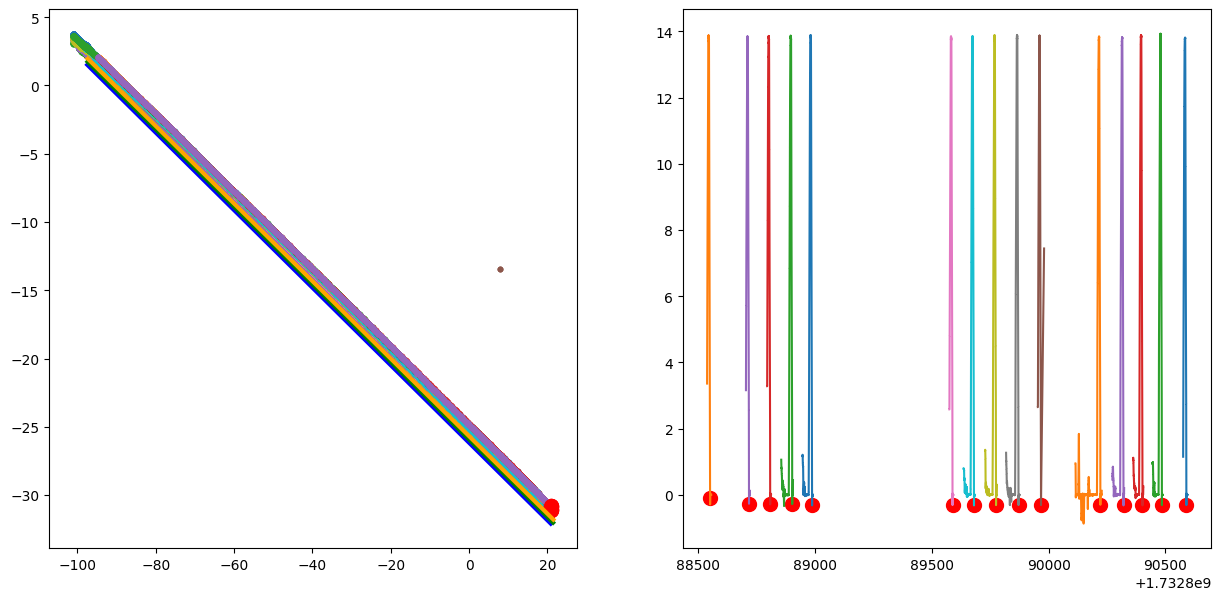

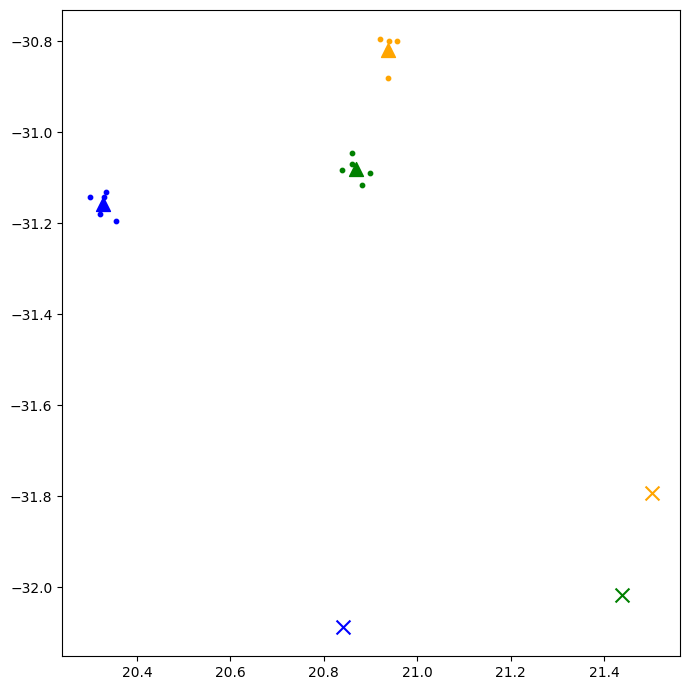

In [8]:
# %matplotlib tk
%matplotlib inline

dir_path = 'logs/CBLA'
colours = ['blue', 'green', 'orange']

fig, (ax_position, ax_velocity) = plt.subplots(1, 2, figsize=(15,7))
fig_stopping_positions = plt.figure(figsize=(7,7))
ax_stopping_positions = fig_stopping_positions.add_subplot(111)

traj_files = ['logs/traj/CBLA/mondeo_50.traj', 'logs/traj/CBLA/mondeo_25.traj', 'logs/traj/CBLA/mondeo_0.traj']
for index, traj_file in enumerate(traj_files):
  traj = get_atos_traj(traj_file)
  ax_position.plot(traj['x'], traj['y'], color=colours[index], linewidth=3)
  ax_stopping_positions.scatter(traj['x'].iloc[-1], traj['y'].iloc[-1], color=colours[index], s=100, marker='x')


for index, directory in enumerate(os.listdir(dir_path)):
  x_values = []
  y_values = []
  time_durations = []
  distances_to_path = []
  traj = get_atos_traj(traj_files[index])
  
  for file_path in os.listdir(os.path.join(dir_path, directory)):
    file_path = os.path.join(dir_path, directory, file_path)
    df = log_to_df(file_path)
    df_mondeo = df.loc[df['client_id'] == 1]
    start_timestamp = df_mondeo[df_mondeo['ready'] == 'RUNNING'].iloc[0]['timestamp']
    
    ax_position, ax_velocity = get_plots(df_mondeo, ax_position, ax_velocity)
    x, y, stopping_timestamp = get_stopping_position(df_mondeo)
    x_values.append(x)
    y_values.append(y)
    time_durations.append(stopping_timestamp - start_timestamp)
    start_timestamp_index = df.index[df['timestamp'] == start_timestamp]
    stopping_timestamp_index = df.index[df['timestamp'] == stopping_timestamp]
    distances_to_path.append(get_average_distance_vehicle_to_path(df[start_timestamp_index[0]:stopping_timestamp_index[0]], traj))
    ax_stopping_positions.scatter(x, y, s=10, color=colours[index], label=directory)
    
  ax_stopping_positions.scatter(np.mean(x_values), np.mean(y_values), s=100, color=colours[index], marker='^', label=directory)
  print(f'Test: {directory} \tMean: ({np.mean(x_values):.2f}, {np.mean(y_values):.2f}) \tStandard deviation: ({np.std(x_values):.2f}, {np.std(y_values):.2f})')
  print(f'Distance from mean to last traj point: {np.linalg.norm([np.mean(x_values) - traj["x"].iloc[-1], np.mean(y_values) - traj["y"].iloc[-1]]):.2f}')
  print(f'Mean time duration: {np.mean(time_durations):.2f} \tStandard deviation: {np.std(time_durations):.2f}')
  print(f'Mean distance to path: {np.mean(distances_to_path):.2f} \tStandard deviation: {np.std(distances_to_path):.2f}')
  print()
  
plt.tight_layout()
plt.show()

